In [115]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_csv(r"D:\Projects\penguins\penguins.csv")
df.isnull().sum()       #looking for missing values

culmen_length_mm     14
culmen_depth_mm      81
flipper_length_mm     2
body_mass_g           2
sex                  10
species               0
dtype: int64

In [117]:
df.duplicated().sum()   #no duplicates found
df.dtypes

culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
species               object
dtype: object

In [118]:
#checking for possible outliers, printing min max value of each column

def find_extremes(column):
    min_val = df[column].min()
    max_val = df[column].max()
    return int(min_val), int(max_val)

print("Culmen length min max values: ",find_extremes("culmen_length_mm"))
print("Culmen depth min max values: ",find_extremes("culmen_depth_mm"))
print("Flipper length min max values: ",find_extremes("flipper_length_mm"))
print("Body mass min max values: ",find_extremes("body_mass_g"))

Culmen length min max values:  (32, 3000)
Culmen depth min max values:  (13, 21)
Flipper length min max values:  (172, 1000)
Body mass min max values:  (2850, 6300)


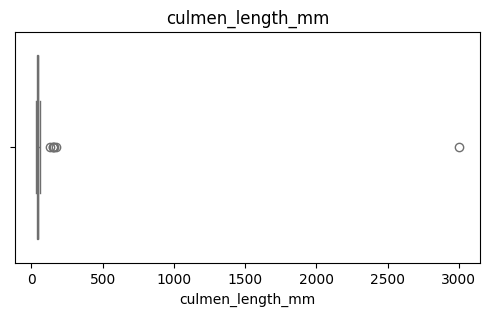

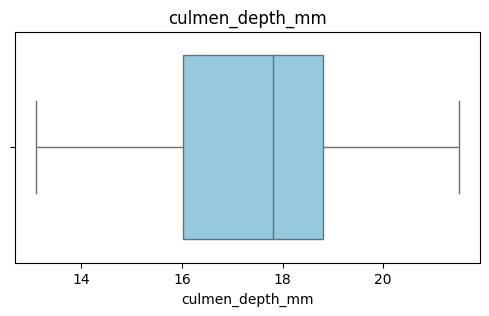

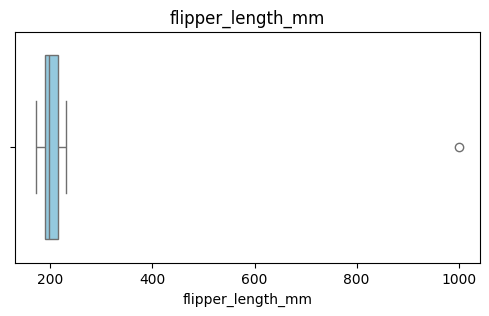

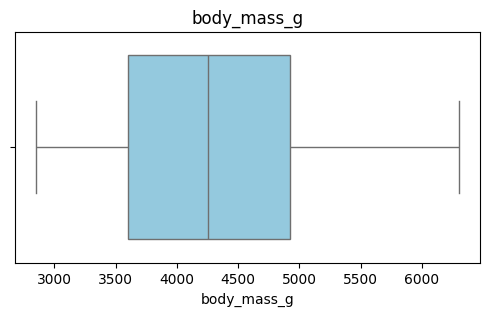

In [119]:
#visual for better understanding  

numeric_cols = df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(col)
    plt.show()

1. Possibly faulty data entry found with outliers being in culmen length and flipper length 
2. Try evaluating algos including and excluding that data point 

Accuracy: 1.0


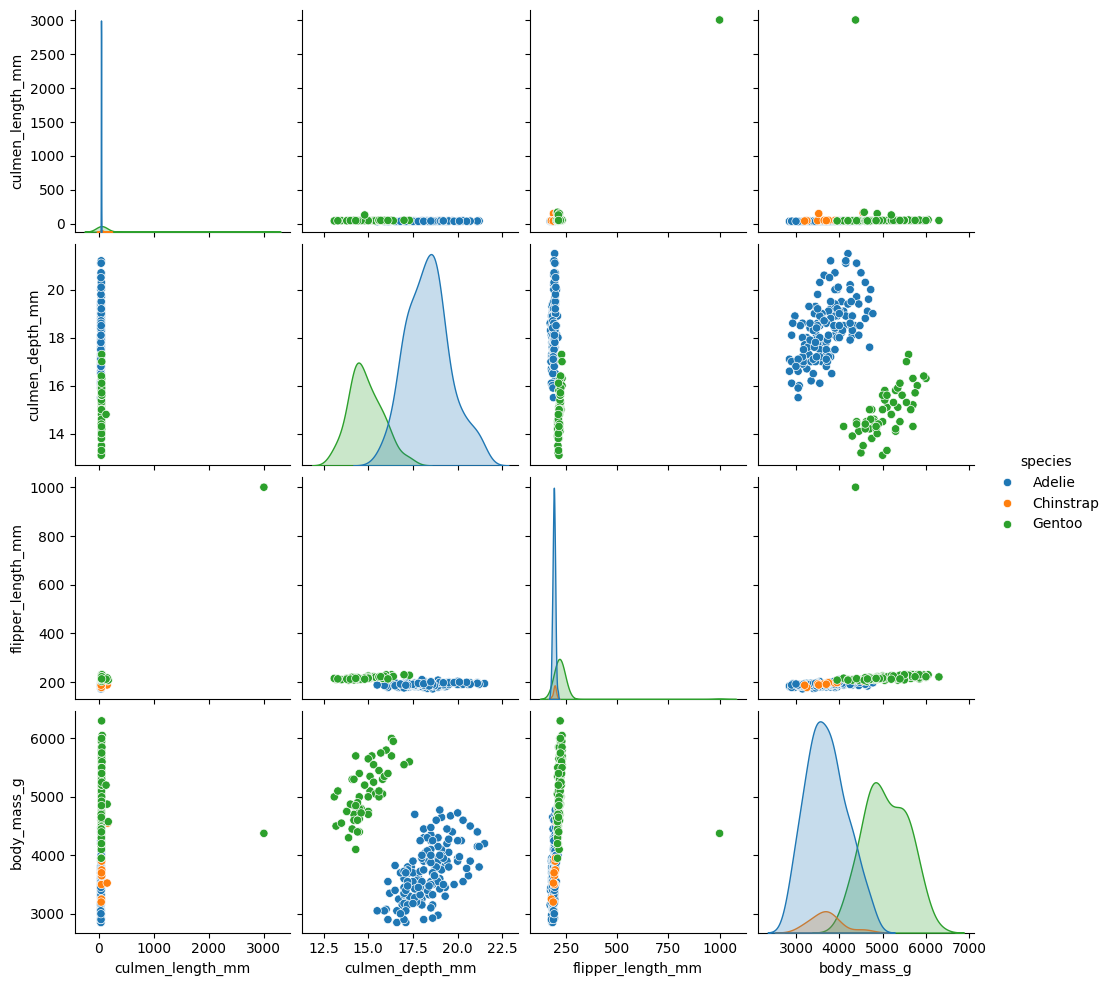

In [120]:
#baseline model 

X = df[["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g", "sex"]]
y = df["species"]

categorical_cols = ["sex"]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))
sns.pairplot(df, hue="species")

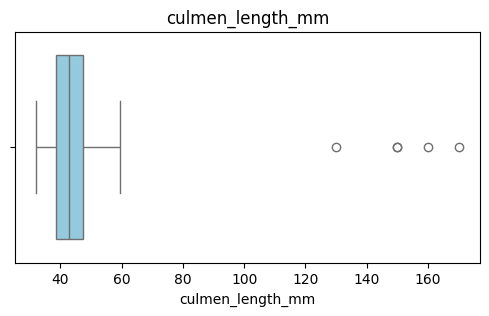

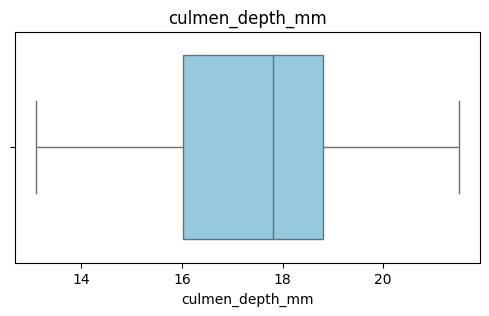

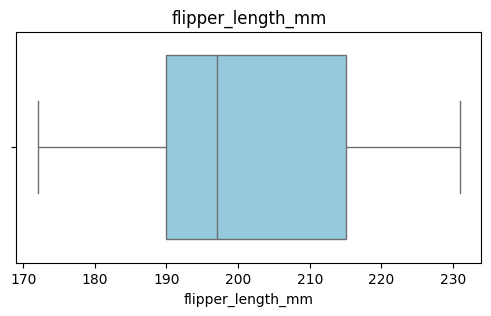

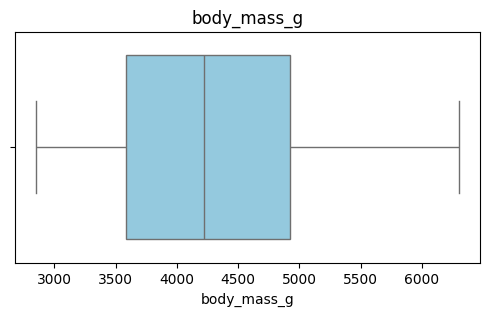

In [ ]:
filtered_df = df[df['culmen_length_mm']!=3000]      #dropping that one entry with absurdly high values 

numeric_cols = filtered_df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=filtered_df[col], color='skyblue')
    plt.title(col)
    plt.show()

1. After dropping one entry with extremely high values, dataset now looks better but still some possible outliers in culmen length 
2. Faced an error "ValueError: Found unknown categories ['M'] in column 0 during transform". Assuming the value was supposed to be entered as "MALE" but an error was made, replacing M. Doing the same for other possible faulty entries. 

Accuracy: 1.0


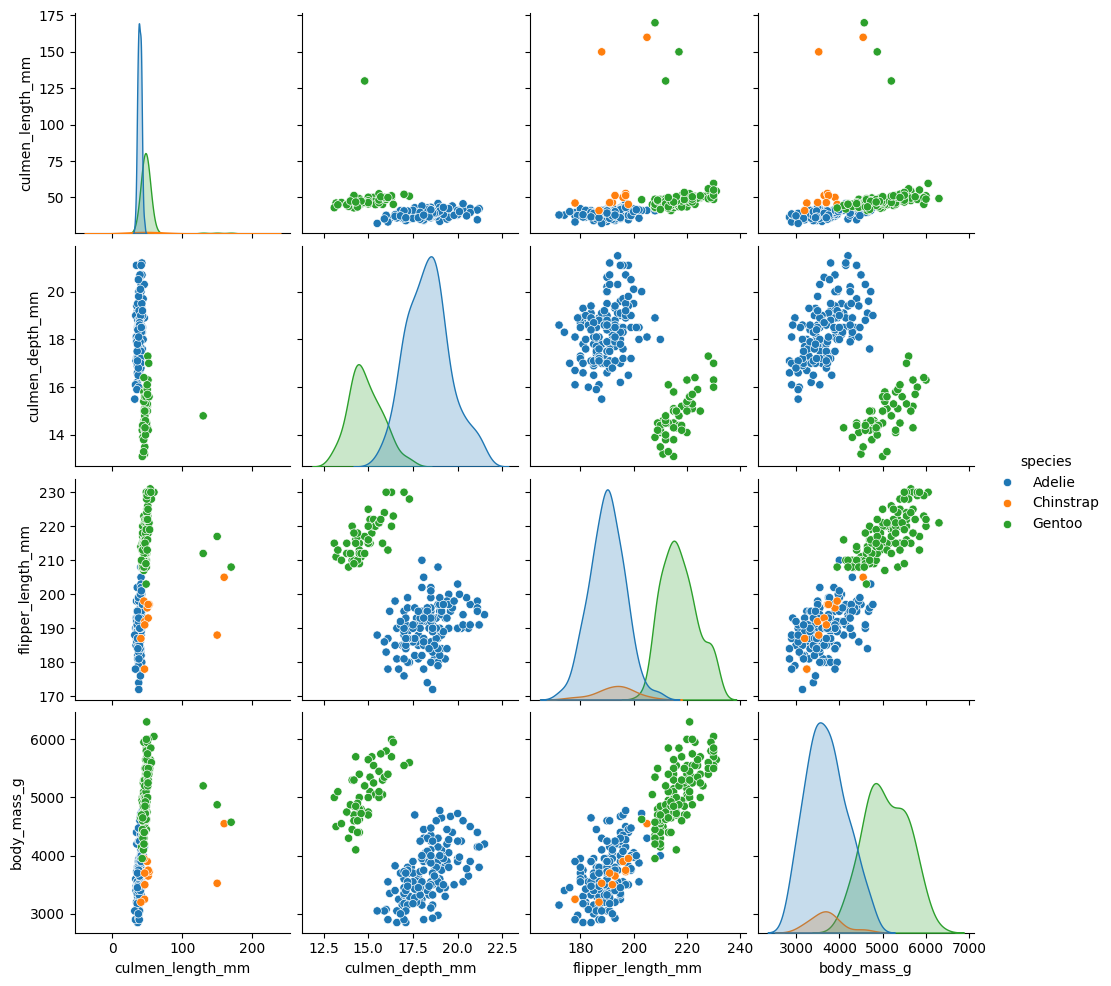

In [126]:
filtered_df = filtered_df.copy()
filtered_df["sex"] = filtered_df["sex"].str.upper().str.strip()
filtered_df["sex"] = filtered_df["sex"].replace({
    "M": "MALE",
    "MA": "MALE",
    "MAL": "MALE",
    "F": "FEMALE",
    "FE": "FEMALE",
    "FEM": "FEMALE",
    "FEMA": "FEMALE",
    "FEMAL": "FEMALE",
    ".": np.nan
})

X = filtered_df[["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g", "sex"]]
y = filtered_df["species"]

categorical_cols = ["sex"]

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), categorical_cols)],
    remainder='passthrough'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))
sns.pairplot(filtered_df, hue="species")

(281, 6)


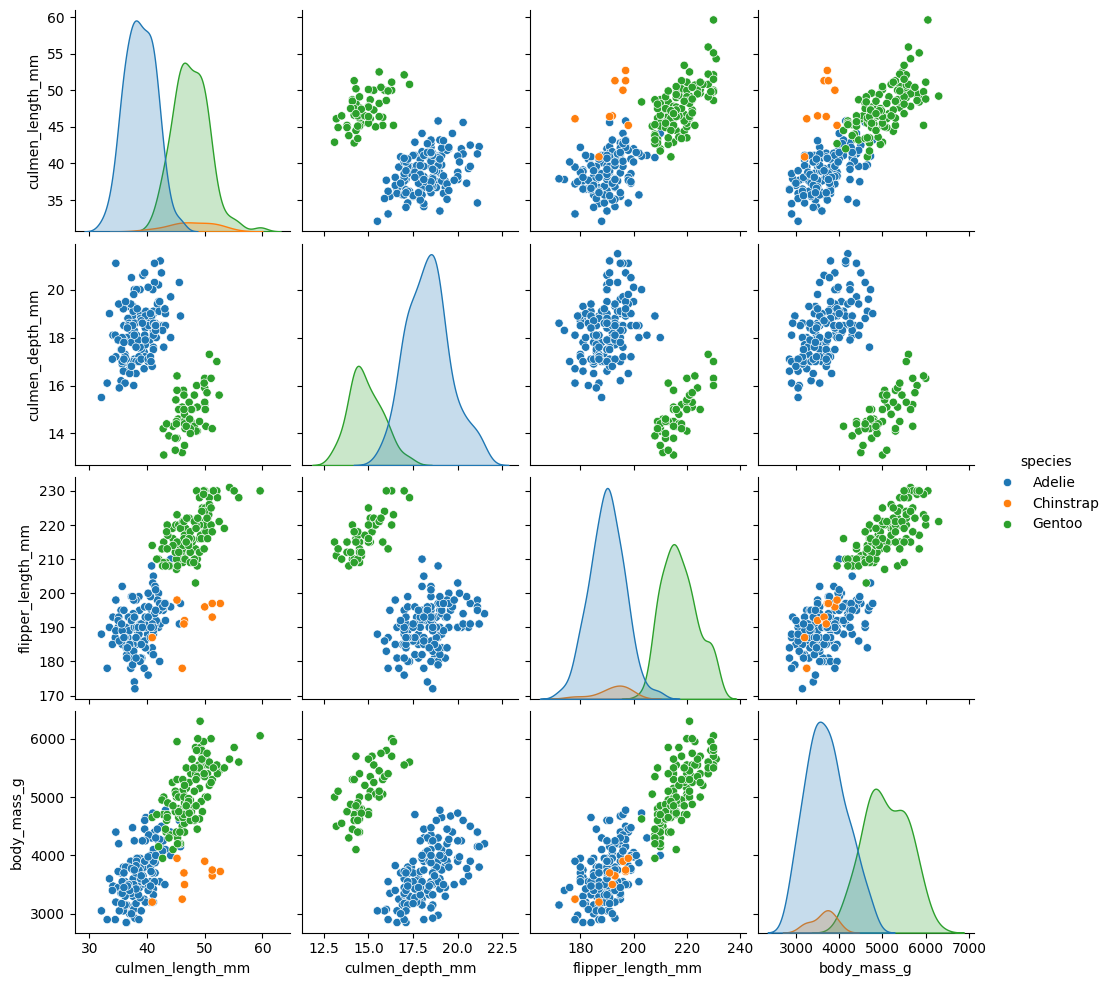

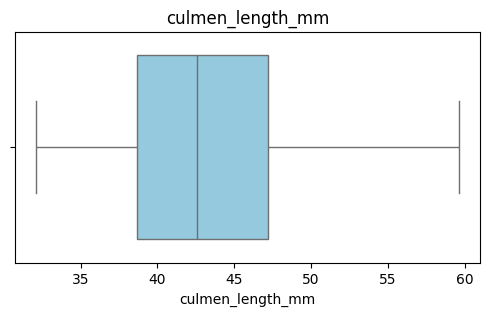

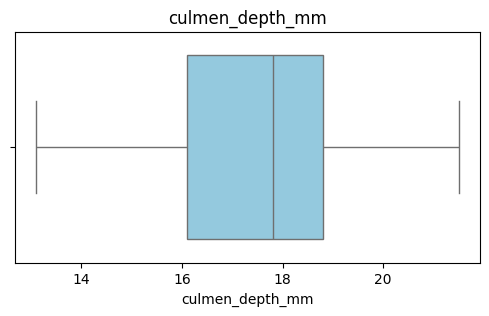

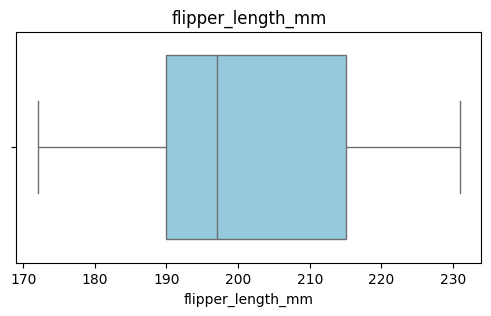

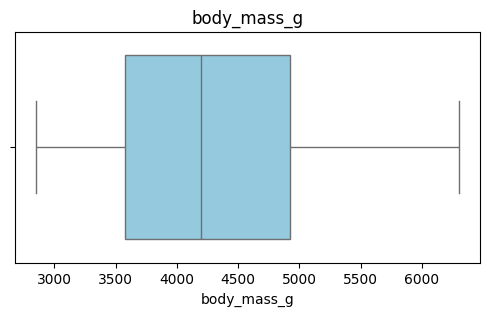

In [ ]:
no_outliers_df=filtered_df
#no_outliers_df=no_outliers_df.copy()
no_outliers_df = no_outliers_df[
    (no_outliers_df['culmen_length_mm'] < 120) | (no_outliers_df['culmen_length_mm'].isna())
]       #dropping all outlier values but keeping NA values 

print(no_outliers_df.shape)

sns.pairplot(no_outliers_df, hue="species")

numeric_cols = no_outliers_df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=no_outliers_df[col], color='skyblue')
    plt.title(col)
    plt.show()

Dataset does not appear to have any outlier values but dropping NA values led to dropping all entries for the species Chinstrap. Trying two different approaches to handle missing values: 1. Dropping entries with missing values 2. Replacing missing values with median values

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

replaced_df = no_outliers_df
replaced_df=replaced_df.copy()

replaced_df["flipper_length_mm"] = replaced_df["flipper_length_mm"].fillna(
    replaced_df["flipper_length_mm"].median()
)
replaced_df["culmen_length_mm"]  = replaced_df["culmen_length_mm"].fillna(
    replaced_df["culmen_length_mm"].median()
)
replaced_df["culmen_depth_mm"]   = replaced_df["culmen_depth_mm"].fillna(
    replaced_df["culmen_depth_mm"].median()
)
replaced_df["body_mass_g"]       = replaced_df["body_mass_g"].fillna(
    replaced_df["body_mass_g"].median()
)
replaced_df["sex"] = replaced_df["sex"].fillna("UNKNOWN")


X = replaced_df[["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g", "sex"]]
y = replaced_df["species"]

categorical_cols = ["sex"]
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    pipe.fit(X_train, y_train)
    accuracy = pipe.score(X_test, y_test)
    print(f"{name}: {accuracy:.3f}")


Logistic Regression: 0.965
Decision Tree: 0.965
Random Forest: 0.965
Gradient Boosting: 0.965
KNN: 0.877
SVM: 0.930
Naive Bayes: 0.965


In [138]:
dropped_missing_df = no_outliers_df.copy()
dropped_missing_df=dropped_missing_df.dropna()

X = dropped_missing_df[["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g", "sex"]]
y = dropped_missing_df["species"]

categorical_cols = ["sex"]
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    pipe.fit(X_train, y_train)
    accuracy = pipe.score(X_test, y_test)
    print(f"{name}: {accuracy:.3f}")


Logistic Regression: 1.000
Decision Tree: 1.000
Random Forest: 1.000
Gradient Boosting: 1.000
KNN: 0.895
SVM: 0.868
Naive Bayes: 1.000
